In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("Insurance_data.csv")


In [3]:
df.head(10)

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2,MEDICAL,A,6000,6.92,0.10,N,3,0
5,5,27,45000,RENT,2,VENTURE,A,9000,8.94,0.20,N,5,0
6,6,25,45000,MORTGAGE,9,EDUCATION,A,12000,6.54,0.27,N,3,0
7,7,21,20000,RENT,0,PERSONAL,C,2500,13.49,0.13,Y,3,0
8,8,37,69600,RENT,11,EDUCATION,D,5000,14.84,0.07,Y,11,0
9,9,35,110000,MORTGAGE,0,DEBTCONSOLIDATION,C,15000,12.98,0.14,Y,6,0


In [4]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  int64  
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(2), int64(7), object

In [6]:
df.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [7]:
df.pivot_table(values='id',index = 'loan_intent', columns = 'loan_status', aggfunc = 'count', margins=True)

loan_status,0,1,All
loan_intent,,,
DEBTCONSOLIDATION,7404,1729,9133
EDUCATION,10949,1322,12271
HOMEIMPROVEMENT,5189,1091,6280
MEDICAL,8985,1949,10934
PERSONAL,8686,1330,10016
VENTURE,9082,929,10011
All,50295,8350,58645


In [8]:
df.pivot_table(values='id',index = 'person_home_ownership', columns = 'loan_status', aggfunc = 'count', margins=True,)

loan_status,0,1,All
person_home_ownership,,,
MORTGAGE,23341,1483,24824
OTHER,74,15,89
OWN,3095,43,3138
RENT,23785,6809,30594
All,50295,8350,58645


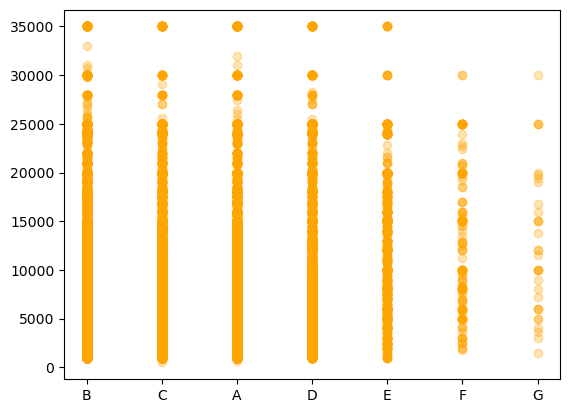

In [9]:
plt.scatter(df['loan_grade'], df['loan_amnt'], color='orange', alpha=0.3)

In [10]:
numerical_df = pd.read_csv("Insurance_data.csv" , usecols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length' , 'loan_status'])

correlation_matrix = numerical_df.corr(method='pearson')
print(correlation_matrix.round(3))



correlation_matrix.round(3).style.background_gradient(cmap ='Greens').set_properties(**{'font-size': '12px'})



                            person_age  person_income  loan_amnt  \
person_age                       1.000          0.102      0.050   
person_income                    0.102          1.000      0.311   
loan_amnt                        0.050          0.311      1.000   
loan_int_rate                    0.010         -0.058      0.114   
loan_percent_income             -0.032         -0.280      0.647   
cb_person_cred_hist_length       0.874          0.083      0.046   
loan_status                     -0.001         -0.170      0.145   

                            loan_int_rate  loan_percent_income  \
person_age                          0.010               -0.032   
person_income                      -0.058               -0.280   
loan_amnt                           0.114                0.647   
loan_int_rate                       1.000                0.152   
loan_percent_income                 0.152                1.000   
cb_person_cred_hist_length          0.008               -0.

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.102000,0.050000,0.010000,-0.032000,0.874000,-0.001000
person_income,0.102000,1.000000,0.311000,-0.058000,-0.280000,0.083000,-0.170000
loan_amnt,0.050000,0.311000,1.000000,0.114000,0.647000,0.046000,0.145000
loan_int_rate,0.010000,-0.058000,0.114000,1.000000,0.152000,0.008000,0.339000
loan_percent_income,-0.032000,-0.280000,0.647000,0.152000,1.000000,-0.023000,0.378000
cb_person_cred_hist_length,0.874000,0.083000,0.046000,0.008000,-0.023000,1.000000,-0.003000
loan_status,-0.001000,-0.170000,0.145000,0.339000,0.378000,-0.003000,1.000000


In [11]:
X = numerical_df.drop(['loan_status' , 'person_age'], axis = 1)
y = numerical_df['loan_status']

In [12]:
from sklearn.model_selection import train_test_split

X_train_2, X_test_2, y_train_2, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42
)

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y,
    test_size=0.1,
    random_state=42
)

In [14]:
# Create logistic regression model using 'liblinear' solver
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(solver='liblinear')

# Fit the model to training data
logreg.fit(X_train_2 , y_train)

LogisticRegression(solver='liblinear')

In [15]:
y_pred_LR = logreg.predict(X_test_2)

In [16]:
precision_score(y_test, y_pred_LR)

0.7261146496815286

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
dtree = DecisionTreeClassifier()
dtree.fit(X_train_2, y_train)

DecisionTreeClassifier()

In [18]:
y_pred_DT = dtree.predict(X_test_2)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_DT)
print("Accuracy:", accuracy)

Accuracy: 0.877919863597613


In [19]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2,MEDICAL,A,6000,6.92,0.10,N,3,0


In [20]:
#bivariate plots and see


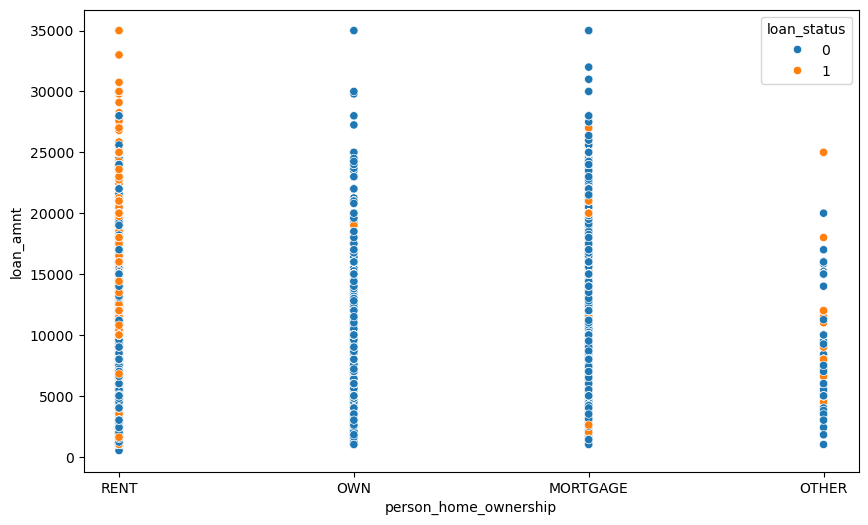

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='person_home_ownership',
    y='loan_amnt',
    hue='loan_status'
)
plt.show()

In [22]:
#WoE 

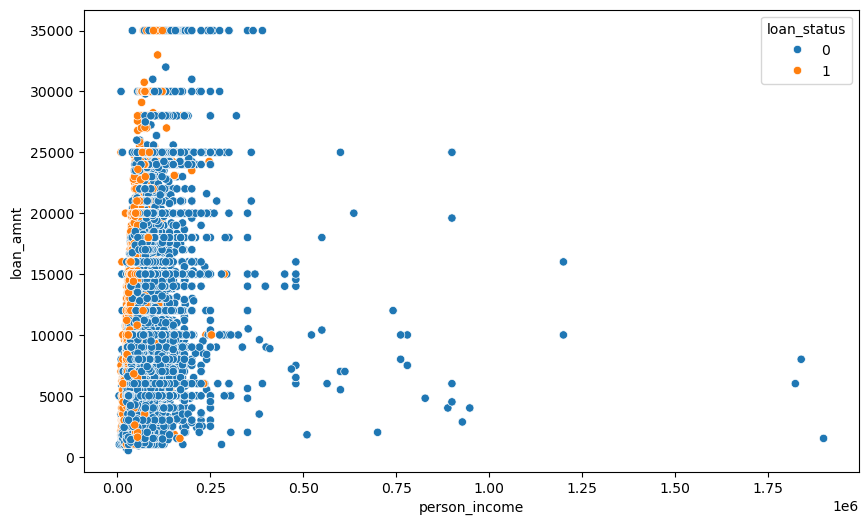

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='person_income',
    y='loan_amnt',
    hue='loan_status'
)
plt.show()

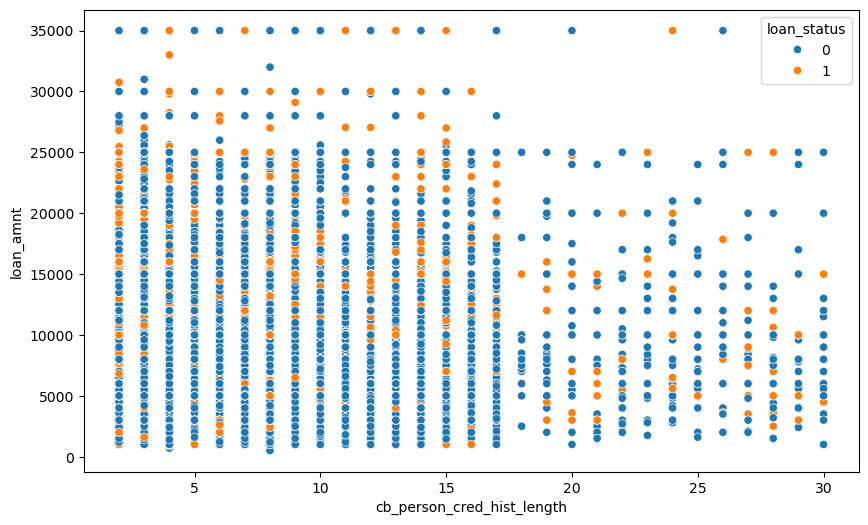

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='cb_person_cred_hist_length',
    y='loan_amnt',
    hue='loan_status'
)
plt.show()


In [25]:
from sklearn.ensemble import RandomForestClassifier
randomforest = RandomForestClassifier(n_estimators=100, random_state=50)
randomforest.fit(X_train_2, y_train)

RandomForestClassifier(random_state=50)

In [46]:
y_pred_RF = randomforest.predict(X_test_2)
accuracy_score(y_pred_RF , y_test)

0.9048593350383631

In [47]:
df.head(2)

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,0,37,35000,RENT,0,EDUCATION,B,6000,11.49,0.17,N,14
1,1,22,56000,OWN,6,MEDICAL,C,4000,13.35,0.07,N,2


In [54]:
import pickle
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder to drop the first category (just like drop_first=True)
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

cat_cols = ['person_home_ownership' , 'loan_intent' , 'loan_grade' , 'cb_person_default_on_file']
encoded_cat = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(encoded_cat, columns= encoder.get_feature_names_out(cat_cols))


df_encoded = pd.concat([df.drop(columns= cat_cols), encoded_df], axis = 1)



# 1. Save the fitted encoder object
joblib.dump(encoder, 'onehot_encoder.pkl')

# 2. Save the final column layout (critical for keeping column order perfect)
model_columns = list(df_encoded.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [52]:
df_encoded.head()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,0,37,35000,0,6000,11.49,0.17,14,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,22,56000,6,4000,13.35,0.07,2,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,29,28800,8,6000,8.90,0.21,10,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,30,70000,14,12000,11.11,0.17,5,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,22,60000,2,6000,6.92,0.10,3,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train_3, X_test_3, y_train_3, y_test = train_test_split(
    df_new, y,
    test_size=0.1,
    random_state=42
)



,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,0,37,35000,0,6000,11.49,0.17,14,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,22,56000,6,4000,13.35,0.07,2,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,29,28800,8,6000,8.90,0.21,10,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,30,70000,14,12000,11.11,0.17,5,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,22,60000,2,6000,6.92,0.10,3,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
randomforest_2 = RandomForestClassifier(n_estimators=100, random_state=50)
randomforest_2.fit(X_train_3, y_train)

RandomForestClassifier(random_state=50)

In [41]:
y_pred_RF_2 = randomforest_2.predict(X_test_3)
accuracy_score(y_pred_RF_2 , y_test)

0.951918158567775

In [42]:
import joblib
joblib.dump(randomforest_2 , 'random_forest_model.pkl')


['random_forest_model.pkl']

In [34]:
import pickle

# Assuming 'model' is your trained model object
with open('random_forest.pkl', 'wb') as file:
    pickle.dump(randomforest_2, file)

print("Model saved")

Model saved


In [44]:
# Save your final encoded dataframe columns to a list
model_columns = list(df_encoded.columns)

# Save this list using pickle
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

In [65]:
headings = df_new.columns

joblib.dump(headings, 'headings.pkl')

['headings.pkl']